# Chapter 3 — VLM Architecture (LLaVA-style)
### *Build a Multimodal Model from Scratch*

---

This chapter solves **four concrete engineering problems** that arise when you try
to connect a Vision Transformer (ViT) to a GPT-style language model.

| # | Problem | Solution |
|---|---------|----------|
| 1 | ViT and GPT live in incompatible vector spaces | `ProjectionMLP` bridge |
| 2 | How to combine image patches + text into one sequence | Visual prefix concatenation |
| 3 | Attention mask is now non-trivial | Hybrid bidirectional/causal mask |
| 4 | Where should the loss apply? | Mask visual positions with `-100` |

By the end, we have a working **VisionLanguageModel** (VLM) that accepts an image
and a text prompt and auto-regressively generates a response.

> **This chapter in context:** Ch03 is the architectural core of the book — it wires the ViT encoder (Ch01) and a GPT language model into a single Vision-Language Model using a ProjectionMLP bridge. The three design patterns introduced here (visual prefix, hybrid attention mask, loss masking on image tokens) are the direct blueprint for LLaVA, InstructBLIP, and Flamingo. Every multimodal chapter that follows — including the audio (Ch08) and video (Ch09) extensions — uses the same wiring diagram.

In [1]:
%matplotlib inline
import math, uuid
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ── Colour palette (used by all figures) ──────────────────────────────────────
PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9',
           orange='#E67E22', green='#27AE60', red='#E74C3C',
           purple='#8E44AD', grey='#95A5A6')

print("Imports OK. Device:", "cuda" if torch.cuda.is_available() else "cpu")

Imports OK. Device: cpu


---
## Problem 1 — ViT and GPT Are Incompatible

A ViT trained on images outputs patch embeddings in **vision space** (dimension
`D_vit`).  A GPT trained on text expects token embeddings in **language space**
(dimension `D_lang`).

Even when `D_vit == D_lang`, the **distributions are completely different**:

* ViT patch vectors after normalisation are roughly unit-sphere points.
* GPT token embeddings are small, dense, and clustered around the origin (~±0.02).

Feeding raw ViT output directly into GPT would be like reading a map that uses
metres while your GPS expects miles — same numbers, wrong meaning.

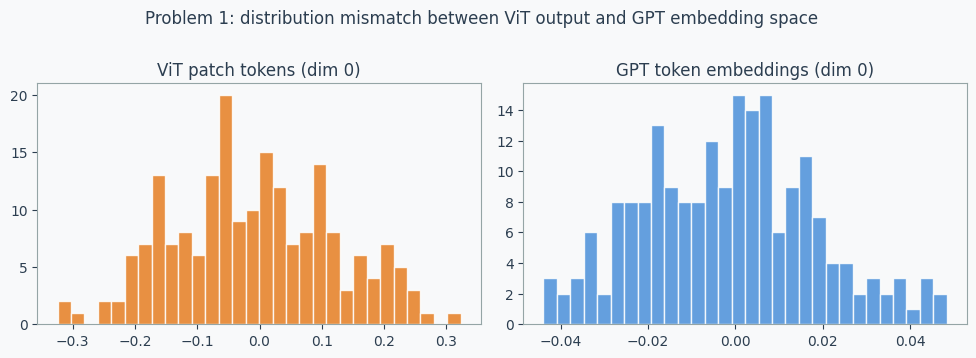

ViT norm (mean):  1.000
GPT norm (mean):  0.161


In [2]:
# Visualise the distribution mismatch
torch.manual_seed(42)
D = 64

# Simulate ViT output: after layer-norm the norms are ~1
vit_tokens  = F.normalize(torch.randn(200, D), dim=-1)
# Simulate GPT token embeddings: initialised N(0, 0.02)
gpt_embeds  = torch.randn(200, D) * 0.02

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), facecolor=PAL['bg'])
fig.suptitle('Problem 1: distribution mismatch between ViT output and GPT embedding space',
             color=PAL['dark'], fontsize=12, y=1.01)

for ax, data, label, colour in zip(
        axes,
        [vit_tokens[:, 0].numpy(), gpt_embeds[:, 0].numpy()],
        ['ViT patch tokens (dim 0)', 'GPT token embeddings (dim 0)'],
        [PAL['orange'], PAL['blue']]):
    ax.hist(data, bins=30, color=colour, alpha=0.85, edgecolor='white')
    ax.set_title(label, color=PAL['dark'])
    ax.set_facecolor(PAL['bg'])
    ax.tick_params(colors=PAL['dark'])
    for sp in ax.spines.values():
        sp.set_edgecolor(PAL['grey'])

plt.tight_layout()
plt.savefig('prob1_distribution_gap.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"ViT norm (mean):  {vit_tokens.norm(dim=-1).mean():.3f}")
print(f"GPT norm (mean):  {gpt_embeds.norm(dim=-1).mean():.3f}")

### Solution 1 — `ProjectionMLP`

A **two-layer MLP** acts as a learned bridge:

```
vision_dim  →  Linear  →  GELU  →  Linear  →  language_dim
```

Why two layers?  A single linear layer can only **rotate and scale** — it cannot
reshape the distribution.  The GELU non-linearity allows the MLP to **remap the
manifold**, pulling the ViT vectors into a region of language space that GPT can
interpret.

In [3]:
class ProjectionMLP(nn.Module):
    """Two-layer MLP bridge: vision_dim → language_dim.

    Why two layers?
        A single linear is just a rotation + scale (can't reshape distributions).
        The GELU activation enables non-linear remapping of the ViT manifold
        into GPT's embedding space.
    """
    def __init__(self, vision_dim: int, language_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(vision_dim, language_dim),
            nn.GELU(),
            nn.Linear(language_dim, language_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, N_patches, vision_dim) → (B, N_patches, language_dim)
        return self.net(x)

# Quick smoke-test
proj = ProjectionMLP(vision_dim=64, language_dim=128)
dummy_vit_out = torch.randn(2, 9, 64)   # batch=2, 9 patches, D_vit=64
out = proj(dummy_vit_out)
print(f"ProjectionMLP: {dummy_vit_out.shape}  →  {out.shape}")
print(f"Parameters: {sum(p.numel() for p in proj.parameters()):,}")

ProjectionMLP: torch.Size([2, 9, 64])  →  torch.Size([2, 9, 128])
Parameters: 24,832


---
## Problem 2 — How to Combine Image and Text into One Sequence

GPT processes a **1-D sequence** of token embeddings.  We have:

* `N` visual patch embeddings  (already projected to `D_lang` by Problem 1)
* `T` text token embeddings

The simplest solution: **concatenate them** to form a single sequence of length
`N + T`, then feed that to GPT.

```
sequence = [VIS₁, VIS₂, …, VIS_N, TXT₁, TXT₂, …, TXT_T]
```

The visual tokens act as a **prefix** — GPT sees the image *before* any text,
so every text token has full access to the visual context.

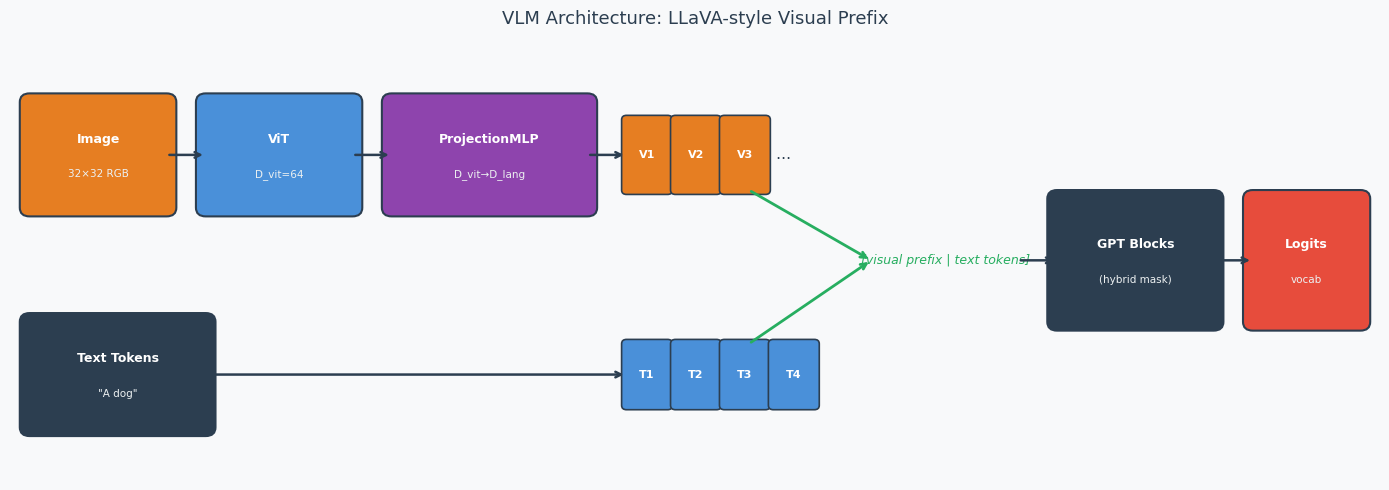

In [4]:
def draw_vlm_architecture():
    fig, ax = plt.subplots(figsize=(14, 5), facecolor=PAL['bg'])
    ax.set_xlim(0, 14); ax.set_ylim(0, 5)
    ax.axis('off')
    ax.set_facecolor(PAL['bg'])
    ax.set_title('VLM Architecture: LLaVA-style Visual Prefix',
                 color=PAL['dark'], fontsize=13, pad=12)

    def box(x, y, w, h, colour, label, sublabel='', fontsize=9):
        rect = FancyBboxPatch((x, y), w, h,
                              boxstyle='round,pad=0.1',
                              linewidth=1.5,
                              edgecolor=PAL['dark'],
                              facecolor=colour)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2 + (0.18 if sublabel else 0),
                label, ha='center', va='center',
                fontsize=fontsize, color='white', fontweight='bold')
        if sublabel:
            ax.text(x + w/2, y + h/2 - 0.22, sublabel,
                    ha='center', va='center', fontsize=7.5, color='#ECF0F1')

    def arrow(x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=PAL['dark'],
                                   lw=1.8))

    # ── Image path (top lane, y=3.1) ─────────────────────────────────────────
    box(0.2, 3.1, 1.4, 1.2, PAL['orange'], 'Image', '32×32 RGB', fontsize=9)
    arrow(1.6, 3.7, 2.0, 3.7)
    box(2.0, 3.1, 1.5, 1.2, PAL['blue'], 'ViT', 'D_vit=64', fontsize=9)
    arrow(3.5, 3.7, 3.9, 3.7)
    box(3.9, 3.1, 2.0, 1.2, PAL['purple'], 'ProjectionMLP', 'D_vit→D_lang', fontsize=9)
    arrow(5.9, 3.7, 6.3, 3.7)

    # Visual tokens
    for i, xi in enumerate([6.3, 6.8, 7.3]):
        rect = FancyBboxPatch((xi, 3.3), 0.42, 0.8,
                              boxstyle='round,pad=0.05',
                              linewidth=1.2,
                              edgecolor=PAL['dark'],
                              facecolor=PAL['orange'])
        ax.add_patch(rect)
        ax.text(xi + 0.21, 3.7, f'V{i+1}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')
    ax.text(7.9, 3.7, '…', ha='center', va='center',
            fontsize=11, color=PAL['dark'])

    # ── Text path (bottom lane, y=0.6) ────────────────────────────────────────
    box(0.2, 0.6, 1.8, 1.2, PAL['dark'], 'Text Tokens', '"A dog"', fontsize=9)
    arrow(2.0, 1.2, 6.3, 1.2)

    # Text tokens
    for i, xi in enumerate([6.3, 6.8, 7.3, 7.8]):
        rect = FancyBboxPatch((xi, 0.85), 0.42, 0.7,
                              boxstyle='round,pad=0.05',
                              linewidth=1.2,
                              edgecolor=PAL['dark'],
                              facecolor=PAL['blue'])
        ax.add_patch(rect)
        ax.text(xi + 0.21, 1.2, f'T{i+1}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

    # ── Combine arrow ─────────────────────────────────────────────────────────
    ax.annotate('', xy=(8.8, 2.5), xytext=(7.55, 3.3),
                arrowprops=dict(arrowstyle='->', color=PAL['green'], lw=2.0))
    ax.annotate('', xy=(8.8, 2.5), xytext=(7.55, 1.55),
                arrowprops=dict(arrowstyle='->', color=PAL['green'], lw=2.0))

    # Concat bracket
    ax.text(8.7, 2.5, '[visual prefix | text tokens]',
            ha='left', va='center', fontsize=9, color=PAL['green'],
            fontstyle='italic')

    # ── GPT blocks ────────────────────────────────────────────────────────────
    arrow(10.3, 2.5, 10.7, 2.5)
    box(10.7, 1.8, 1.6, 1.4, PAL['dark'], 'GPT Blocks', '(hybrid mask)', fontsize=9)
    arrow(12.3, 2.5, 12.7, 2.5)
    box(12.7, 1.8, 1.1, 1.4, PAL['red'], 'Logits', 'vocab', fontsize=9)

    plt.tight_layout()
    plt.savefig('vlm_architecture.png', dpi=110, bbox_inches='tight')
    plt.show()

draw_vlm_architecture()

---
## Problem 3 — The Attention Mask Is Now Non-Trivial

In a text-only GPT, every token can see only past tokens (causal mask).
Now our sequence has **two kinds of tokens with different rules**:

| Query \ Key | Visual tokens | Past text tokens | Future text tokens |
|---|---|---|---|
| **Visual token** | ✅ attend (bidirectional) | — | — |
| **Text token** | ✅ attend (image gives context) | ✅ attend | ❌ blocked (causal) |

This creates a **hybrid mask**: the top-left block (vis→vis) is fully open,
the bottom-left block (text→vis) is fully open, and the bottom-right block
(text→text) uses the standard causal lower triangle.

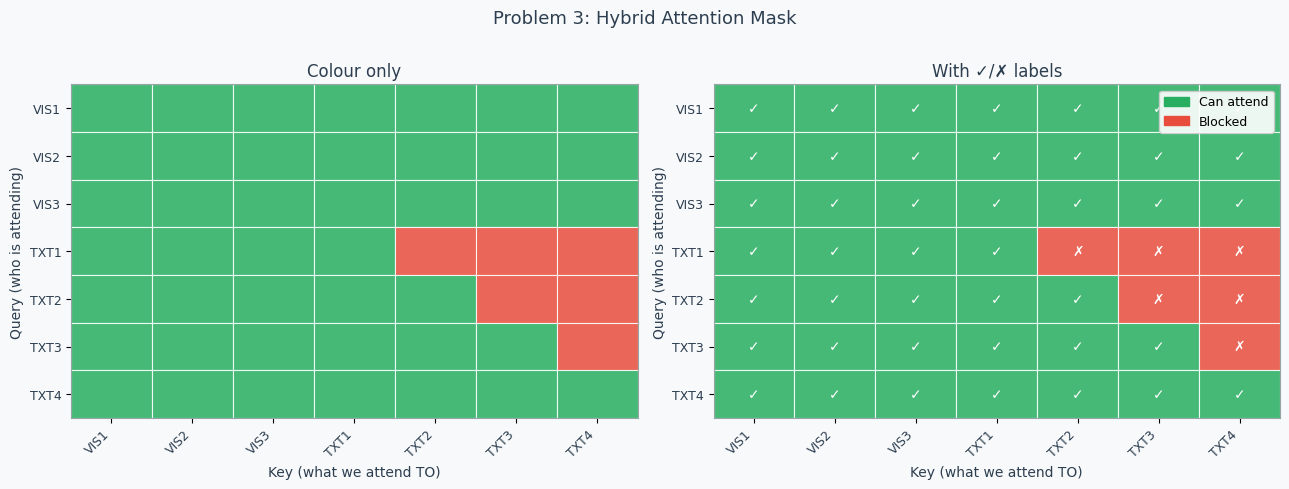

Visual tokens (VIS) attend BIDIRECTIONALLY — they see each other fully.
Text tokens (TXT) see ALL visual tokens + only PAST text tokens.


In [5]:
def draw_attention_mask_table(n_vis=3, n_txt=4):
    N = n_vis + n_txt
    # Build the mask: True = BLOCKED
    mask = np.triu(np.ones((N, N)), k=1).astype(bool)
    mask[:n_vis, :] = False           # vis tokens attend all
    mask[n_vis:, :n_vis] = False      # text tokens attend all visual

    labels = [f'VIS{i+1}' for i in range(n_vis)] + [f'TXT{j+1}' for j in range(n_txt)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), facecolor=PAL['bg'])
    fig.suptitle('Problem 3: Hybrid Attention Mask',
                 color=PAL['dark'], fontsize=13, y=1.01)

    for ax_idx, ax in enumerate(axes):
        ax.set_facecolor(PAL['bg'])
        for row in range(N):
            for col in range(N):
                blocked = mask[row, col]
                colour = PAL['red'] if blocked else PAL['green']
                rect = plt.Rectangle((col, N-1-row), 1, 1,
                                     linewidth=0.8,
                                     edgecolor='white',
                                     facecolor=colour,
                                     alpha=0.85)
                ax.add_patch(rect)
                if ax_idx == 1:
                    symbol = '✗' if blocked else '✓'
                    ax.text(col + 0.5, N-1-row + 0.5, symbol,
                            ha='center', va='center', fontsize=10,
                            color='white', fontweight='bold')

        ax.set_xlim(0, N); ax.set_ylim(0, N)
        ax.set_xticks([i + 0.5 for i in range(N)])
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9, color=PAL['dark'])
        ax.set_yticks([i + 0.5 for i in range(N)])
        ax.set_yticklabels(list(reversed(labels)), fontsize=9, color=PAL['dark'])
        ax.set_xlabel('Key (what we attend TO)', color=PAL['dark'], fontsize=10)
        ax.set_ylabel('Query (who is attending)', color=PAL['dark'], fontsize=10)
        for sp in ax.spines.values():
            sp.set_edgecolor(PAL['grey'])

    axes[0].set_title('Colour only', color=PAL['dark'])
    axes[1].set_title('With ✓/✗ labels', color=PAL['dark'])

    # Legend
    legend_patches = [
        mpatches.Patch(color=PAL['green'], label='Can attend'),
        mpatches.Patch(color=PAL['red'],   label='Blocked'),
    ]
    axes[1].legend(handles=legend_patches, loc='upper right',
                   framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.savefig('attention_mask.png', dpi=110, bbox_inches='tight')
    plt.show()

draw_attention_mask_table(n_vis=3, n_txt=4)
print("Visual tokens (VIS) attend BIDIRECTIONALLY — they see each other fully.")
print("Text tokens (TXT) see ALL visual tokens + only PAST text tokens.")

### Solution 3 — `GPTBlock._build_mask`

The mask is built once per forward call, incorporating `n_visual` to know
where the visual prefix ends and the text begins.

In [6]:
class GPTBlock(nn.Module):
    """Standard Pre-LN transformer block with hybrid visual/causal mask."""

    def __init__(self, embed_dim: int, n_heads: int):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff    = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim),
        )

    def _build_mask(self, T: int, n_visual: int, device) -> torch.Tensor:
        """
        Returns an additive attention-bias mask of shape (T, T).

        Rules:
          • Visual tokens attend to ALL positions  (rows 0..n_visual-1 = all False)
          • Text tokens see ALL visual tokens       (cols 0..n_visual-1 for text rows = False)
          • Text tokens use causal masking for text (upper-right text block = True → -inf)
        """
        # Start: standard upper-triangle causal mask (True = blocked)
        mask = torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()
        # Visual rows: bidirectional — unblock everything
        mask[:n_visual, :] = False
        # Text rows: unblock visual columns
        mask[n_visual:, :n_visual] = False
        # Convert bool → float (-inf for blocked, 0 for allowed)
        float_mask = torch.zeros(T, T, device=device)
        float_mask[mask] = float('-inf')
        return float_mask

    def forward(self, x: torch.Tensor, n_visual: int = 0) -> torch.Tensor:
        T = x.size(1)
        mask = self._build_mask(T, n_visual, x.device)
        # Pre-LayerNorm attention
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed, attn_mask=mask)
        x = x + attn_out
        # Pre-LayerNorm feed-forward
        x = x + self.ff(self.norm2(x))
        return x

# Verify the mask shape
blk = GPTBlock(embed_dim=128, n_heads=4)
mask_test = blk._build_mask(T=7, n_visual=3, device='cpu')
print("Mask (T=7, n_visual=3):")
print(mask_test)
print("Shape:", mask_test.shape)

Mask (T=7, n_visual=3):
tensor([[0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0.]])
Shape: torch.Size([7, 7])


---
## Problem 4 — Where Should the Loss Apply?

In next-token prediction, the model predicts token `t+1` from tokens `0..t`.
If we compute loss at **visual token positions**, we are asking GPT to predict
the next patch embedding — which is nonsensical (patch embeddings are not in
the vocabulary).

The fix: set labels at visual positions to **`-100`**.
PyTorch's `F.cross_entropy` ignores positions where the label is `-100`.

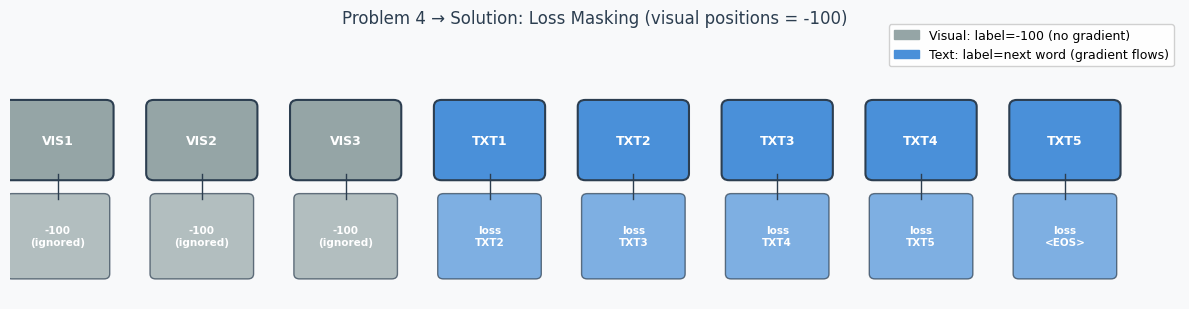

In [7]:
def draw_loss_masking(n_vis=3, n_txt=5):
    N = n_vis + n_txt
    labels_shown = (
        ['-100\n(ignored)'] * n_vis +
        ['loss\nTXT2', 'loss\nTXT3', 'loss\nTXT4', 'loss\nTXT5', 'loss\n<EOS>'][:n_txt]
    )
    colours = [PAL['grey']] * n_vis + [PAL['blue']] * n_txt
    token_names = ([f'VIS{i+1}' for i in range(n_vis)] +
                   [f'TXT{j+1}' for j in range(n_txt)])

    fig, ax = plt.subplots(figsize=(12, 3.2), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    ax.set_title('Problem 4 → Solution: Loss Masking (visual positions = -100)',
                 color=PAL['dark'], fontsize=12)
    ax.axis('off')

    for i in range(N):
        x = 0.5 + i * 1.5
        # Token box
        rect = FancyBboxPatch((x - 0.5, 1.5), 1.0, 0.8,
                              boxstyle='round,pad=0.08',
                              linewidth=1.5, edgecolor=PAL['dark'],
                              facecolor=colours[i])
        ax.add_patch(rect)
        ax.text(x, 1.9, token_names[i], ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

        # Label bar below
        bar_col = PAL['grey'] if i < n_vis else PAL['blue']
        rect2 = FancyBboxPatch((x - 0.48, 0.3), 0.96, 0.9,
                               boxstyle='round,pad=0.06',
                               linewidth=1.0, edgecolor=PAL['dark'],
                               facecolor=bar_col, alpha=0.7)
        ax.add_patch(rect2)
        ax.text(x, 0.75, labels_shown[i], ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold')

        # Connecting line
        ax.plot([x, x], [1.5, 1.2], color=PAL['dark'], lw=1)

    # Legend (mpatches.Patch is only valid in legend handles, not ax.add_patch)
    handles = [
        mpatches.Patch(color=PAL['grey'], label='Visual: label=-100 (no gradient)'),
        mpatches.Patch(color=PAL['blue'], label='Text: label=next word (gradient flows)'),
    ]
    ax.legend(handles=handles, loc='upper right', framealpha=0.9, fontsize=9,
              bbox_to_anchor=(1.0, 1.05))

    ax.set_xlim(0, N * 1.5 + 0.2)
    ax.set_ylim(0, 3.2)
    plt.tight_layout()
    plt.savefig('loss_masking.png', dpi=110, bbox_inches='tight')
    plt.show()

draw_loss_masking(n_vis=3, n_txt=5)

### Full GPT Decoder with Visual Prefix Support

In [8]:
class GPTDecoder(nn.Module):
    """
    GPT-style auto-regressive decoder that accepts an optional visual_prefix.

    forward(input_ids, visual_prefix=None) -> (logits, n_visual)

    Weight tying: lm_head.weight == token_embed.weight  (reduces parameters,
    improves generalisation — output space mirrors input embedding space).
    """

    def __init__(self, vocab_size: int, embed_dim: int, depth: int,
                 n_heads: int, max_seq: int = 512):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed   = nn.Embedding(max_seq, embed_dim)
        self.blocks      = nn.ModuleList([
            GPTBlock(embed_dim, n_heads) for _ in range(depth)
        ])
        self.norm     = nn.LayerNorm(embed_dim)
        self.lm_head  = nn.Linear(embed_dim, vocab_size, bias=False)
        # Weight tying
        self.lm_head.weight = self.token_embed.weight

    def forward(self, input_ids: torch.Tensor,
                visual_prefix: torch.Tensor | None = None):
        """
        input_ids:     (B, T)
        visual_prefix: (B, N, D)  or None
        returns:       logits (B, N+T, vocab_size), n_visual (int)
        """
        B, T = input_ids.shape
        tok = self.token_embed(input_ids)                   # (B, T, D)

        n_visual = 0
        if visual_prefix is not None:
            n_visual = visual_prefix.size(1)
            # Positional encoding for text tokens only (0..T-1)
            positions = torch.arange(T, device=input_ids.device)
            tok = tok + self.pos_embed(positions)
            # Prepend visual prefix (no positional encoding — position comes from ViT)
            x = torch.cat([visual_prefix, tok], dim=1)      # (B, N+T, D)
        else:
            positions = torch.arange(T, device=input_ids.device)
            tok = tok + self.pos_embed(positions)
            x = tok

        total_len = x.size(1)
        for blk in self.blocks:
            x = blk(x, n_visual=n_visual)

        x = self.norm(x)
        logits = self.lm_head(x)                            # (B, N+T, vocab_size)
        return logits, n_visual

# Smoke-test
gpt = GPTDecoder(vocab_size=1000, embed_dim=128, depth=2, n_heads=4, max_seq=64)
ids = torch.randint(0, 1000, (2, 6))
vis = torch.randn(2, 4, 128)
logits, nv = gpt(ids, visual_prefix=vis)
print(f"logits shape: {logits.shape}   n_visual: {nv}")
print(f"GPT parameters: {sum(p.numel() for p in gpt.parameters()):,}")

logits shape: torch.Size([2, 10, 1000])   n_visual: 4
GPT parameters: 532,992


---
## Assembling the Complete VLM

We need a minimal Vision Transformer that can return **all patch tokens**
(not just the CLS token) when `return_all_tokens=True`.

In [9]:
# ── Minimal Vision Transformer ───────────────────────────────────────────────

class PatchEmbedding(nn.Module):
    """Split image into patches and project each to embed_dim."""
    def __init__(self, img_size=32, patch_size=8, in_channels=3, embed_dim=64):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W) → (B, N_patches, embed_dim)
        x = self.proj(x)                          # (B, D, h, w)
        B, D, h, w = x.shape
        return x.flatten(2).transpose(1, 2)       # (B, N, D)


class ViTBlock(nn.Module):
    def __init__(self, embed_dim, n_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff    = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim), nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim),
        )

    def forward(self, x):
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    """
    Small ViT.  When return_all_tokens=True, returns (B, N_patches, D)
    instead of the CLS token only.
    """
    def __init__(self, img_size=32, patch_size=8,
                 embed_dim=64, depth=2, n_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.blocks    = nn.ModuleList([ViTBlock(embed_dim, n_heads) for _ in range(depth)])
        self.norm      = nn.LayerNorm(embed_dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x, return_all_tokens=False):
        B = x.size(0)
        patches = self.patch_embed(x)                         # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, patches], dim=1)                # (B, N+1, D)
        x   = x + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        if return_all_tokens:
            return x[:, 1:, :]   # drop CLS, return all patch tokens
        return x[:, 0, :]        # CLS only

# Quick test
vit = VisionTransformer(img_size=32, patch_size=8, embed_dim=64, depth=2, n_heads=4)
imgs = torch.randn(2, 3, 32, 32)
patch_tokens = vit(imgs, return_all_tokens=True)
print(f"ViT patch tokens: {patch_tokens.shape}   (B, N_patches, D_vit)")

ViT patch tokens: torch.Size([2, 16, 64])   (B, N_patches, D_vit)


In [10]:
class VisionLanguageModel(nn.Module):
    """
    Full VLM: ViT + ProjectionMLP + GPTDecoder.

    Training stages:
        Stage 1 (alignment): freeze ViT + GPT, train only ProjectionMLP
        Stage 2 (instruction): freeze ViT, train ProjectionMLP + GPT
    """

    def __init__(self,
                 img_size=32, patch_size=8, vision_dim=64, vision_depth=2, vision_heads=4,
                 vocab_size=1000, language_dim=128, language_depth=2, language_heads=4,
                 max_seq=128):
        super().__init__()
        self.vit        = VisionTransformer(img_size, patch_size,
                                            vision_dim, vision_depth, vision_heads)
        self.projection = ProjectionMLP(vision_dim, language_dim)
        self.gpt        = GPTDecoder(vocab_size, language_dim,
                                     language_depth, language_heads, max_seq)

    def forward(self, images: torch.Tensor,
                input_ids: torch.Tensor,
                labels: torch.Tensor | None = None):
        """
        images:    (B, 3, H, W)
        input_ids: (B, T)
        labels:    (B, T)  optional — -100 at positions to ignore

        Returns dict with 'logits' and optionally 'loss'.
        """
        # Step 1 — encode image into patch tokens
        patch_tokens   = self.vit(images, return_all_tokens=True)  # (B, N, D_vit)
        # Step 2 — project into language space
        visual_prefix  = self.projection(patch_tokens)             # (B, N, D_lang)
        # Step 3 — GPT forward with visual prefix
        logits, n_vis  = self.gpt(input_ids, visual_prefix)        # (B, N+T, vocab)

        out = {'logits': logits}

        if labels is not None:
            # Align: predictions at positions n_vis..n_vis+T-2 predict labels 1..T-1
            # (standard next-token shift, restricted to text positions)
            shift_logits = logits[:, n_vis:-1, :].contiguous()     # (B, T-1, vocab)
            shift_labels = labels[:, 1:].contiguous()              # (B, T-1)
            # Positions where label==-100 are automatically ignored by cross_entropy
            loss = F.cross_entropy(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1),
                ignore_index=-100
            )
            out['loss'] = loss

        return out

    # ── Training-stage helpers ────────────────────────────────────────────────
    def set_stage1(self):
        """Freeze ViT + GPT; train projection only (alignment stage)."""
        for p in self.vit.parameters():  p.requires_grad = False
        for p in self.gpt.parameters():  p.requires_grad = False
        for p in self.projection.parameters(): p.requires_grad = True
        print("Stage 1: training ProjectionMLP only")

    def set_stage2(self):
        """Freeze ViT; train projection + GPT (instruction-following stage)."""
        for p in self.vit.parameters():  p.requires_grad = False
        for p in self.projection.parameters(): p.requires_grad = True
        for p in self.gpt.parameters():  p.requires_grad = True
        print("Stage 2: training ProjectionMLP + GPT")

---
## Forward Pass Verification

Let's instantiate a small VLM and trace shapes at every step.

In [11]:
vlm = VisionLanguageModel(
    img_size=32, patch_size=8,
    vision_dim=64, vision_depth=2, vision_heads=4,
    vocab_size=1000, language_dim=128, language_depth=2, language_heads=4,
    max_seq=128
)
vlm.eval()

# Dummy batch
B      = 2
images = torch.randn(B, 3, 32, 32)
ids    = torch.randint(0, 1000, (B, 12))
# Labels: visual positions -100, text positions are next-token ids
n_vis  = vlm.vit.patch_embed.n_patches   # = (32/8)^2 = 16
labels = ids.clone()
# (Labels here are just for shape verification — not meaningful values)

print("=" * 50)
print(f"Input image:       {images.shape}")
print(f"Input token ids:   {ids.shape}")

patch_tokens  = vlm.vit(images, return_all_tokens=True)
print(f"\n[ViT]  patch_tokens:   {patch_tokens.shape}")

vis_prefix    = vlm.projection(patch_tokens)
print(f"[Proj] visual_prefix:   {vis_prefix.shape}")

logits, nv    = vlm.gpt(ids, vis_prefix)
print(f"[GPT]  logits:          {logits.shape}   n_visual={nv}")

# Loss
out = vlm(images, ids, labels=labels)
print(f"\n[Loss] cross_entropy:  {out['loss'].item():.4f}  (random init — ~log(vocab)={math.log(1000):.2f})")

Input image:       torch.Size([2, 3, 32, 32])
Input token ids:   torch.Size([2, 12])



[ViT]  patch_tokens:   torch.Size([2, 16, 64])


[Proj] visual_prefix:   torch.Size([2, 16, 128])


[GPT]  logits:          torch.Size([2, 28, 1000])   n_visual=16



[Loss] cross_entropy:  85.6892  (random init — ~log(vocab)=6.91)


---
## Parameter Distribution by Component

`ProjectionMLP` is designed to be tiny — the key insight is that we don't
need many parameters to *translate* between two already-rich embedding spaces.

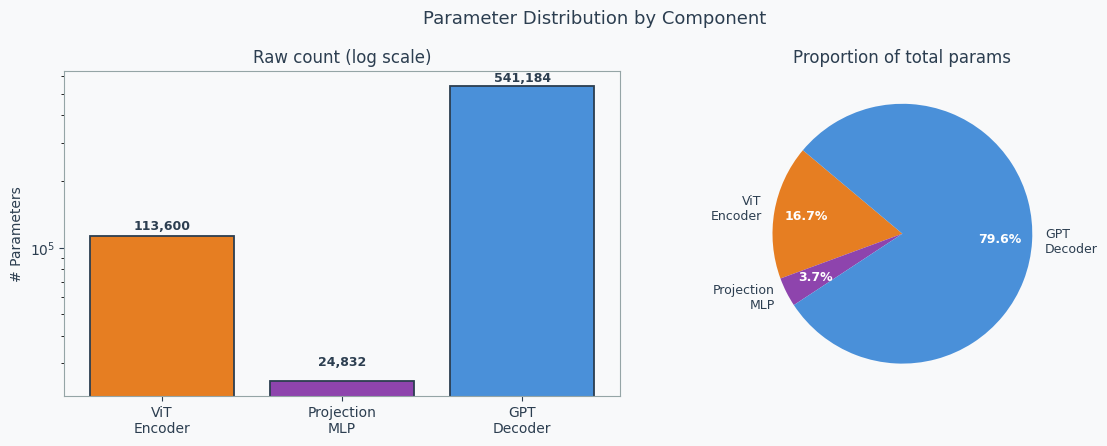

Total parameters: 679,616
  ViT Encoder           :  113,600  (16.7%)
  Projection MLP        :   24,832  (3.7%)
  GPT Decoder           :  541,184  (79.6%)


In [12]:
def plot_parameter_count(vlm):
    counts = {
        'ViT\nEncoder':      sum(p.numel() for p in vlm.vit.parameters()),
        'Projection\nMLP':   sum(p.numel() for p in vlm.projection.parameters()),
        'GPT\nDecoder':      sum(p.numel() for p in vlm.gpt.parameters()),
    }
    total = sum(counts.values())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor=PAL['bg'])
    fig.suptitle('Parameter Distribution by Component', color=PAL['dark'], fontsize=13)

    colours = [PAL['orange'], PAL['purple'], PAL['blue']]
    names   = list(counts.keys())
    vals    = list(counts.values())

    # ── Bar chart ────────────────────────────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor(PAL['bg'])
    bars = ax.bar(names, vals, color=colours, edgecolor=PAL['dark'], linewidth=1.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + total * 0.005,
                f'{v:,}', ha='center', va='bottom',
                fontsize=9, color=PAL['dark'], fontweight='bold')
    ax.set_ylabel('# Parameters', color=PAL['dark'])
    ax.set_title('Raw count (log scale)', color=PAL['dark'])
    ax.set_yscale('log')
    ax.tick_params(colors=PAL['dark'])
    for sp in ax.spines.values():
        sp.set_edgecolor(PAL['grey'])

    # ── Pie chart ─────────────────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor(PAL['bg'])
    wedges, texts, autotexts = ax2.pie(
        vals, labels=names, colors=colours,
        autopct='%1.1f%%', startangle=140,
        pctdistance=0.75,
        textprops={'color': PAL['dark'], 'fontsize': 9}
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_color('white')
        at.set_fontweight('bold')
    ax2.set_title('Proportion of total params', color=PAL['dark'])

    plt.tight_layout()
    plt.savefig('param_distribution.png', dpi=110, bbox_inches='tight')
    plt.show()

    print(f"Total parameters: {total:,}")
    for name, cnt in counts.items():
        pct = 100 * cnt / total
        print(f"  {name.replace(chr(10), ' '):<22}: {cnt:>8,}  ({pct:.1f}%)")

plot_parameter_count(vlm)

---
## Two-Stage Training Strategy

LLaVA and similar VLMs use a **two-stage training recipe**:

### Stage 1 — Alignment (cheap)
Freeze both ViT and GPT.  Train **only** the `ProjectionMLP`.
Goal: teach the bridge to translate ViT output into GPT-compatible tokens.
Requires: image-caption pairs (e.g., CC3M).

### Stage 2 — Instruction Tuning (expensive)
Freeze ViT.  Train `ProjectionMLP` + `GPT`.
Goal: teach the model to follow instructions about images.
Requires: high-quality instruction-following data (e.g., LLaVA-Instruct-150K).

In [13]:
# Demonstrate parameter freezing
print("─── Stage 1: alignment ───────────────────────────────────")
vlm.set_stage1()
trainable_s1 = sum(p.numel() for p in vlm.parameters() if p.requires_grad)
total_params  = sum(p.numel() for p in vlm.parameters())
print(f"  Trainable: {trainable_s1:,} / {total_params:,}  ({100*trainable_s1/total_params:.1f}%)")

print("\n─── Stage 2: instruction tuning ─────────────────────────")
vlm.set_stage2()
trainable_s2 = sum(p.numel() for p in vlm.parameters() if p.requires_grad)
print(f"  Trainable: {trainable_s2:,} / {total_params:,}  ({100*trainable_s2/total_params:.1f}%)")

─── Stage 1: alignment ───────────────────────────────────
Stage 1: training ProjectionMLP only
  Trainable: 24,832 / 679,616  (3.7%)

─── Stage 2: instruction tuning ─────────────────────────
Stage 2: training ProjectionMLP + GPT
  Trainable: 566,016 / 679,616  (83.3%)


---
## End-to-End: Greedy Generation

A mini-demonstration of auto-regressive generation with the VLM.
(Tokens are random vocabulary ids — this illustrates the *mechanism*, not meaning.)

In [14]:
@torch.no_grad()
def greedy_generate(vlm, image, prompt_ids, max_new=8):
    """
    Auto-regressively generate max_new tokens given an image + prompt prefix.
    """
    vlm.eval()
    B = image.size(0)
    generated = prompt_ids.clone()           # (B, T_prompt)

    for step in range(max_new):
        out    = vlm(image, generated)
        logits = out['logits']               # (B, N_vis+T, vocab)
        # Take the last text-position logit
        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)  # (B, 1)
        generated = torch.cat([generated, next_id], dim=1)

    return generated

# Run it
image     = torch.randn(1, 3, 32, 32)
prompt    = torch.tensor([[42, 7, 19]])        # 3-token prompt
generated = greedy_generate(vlm, image, prompt, max_new=8)
print(f"Prompt ids:    {prompt[0].tolist()}")
print(f"Generated ids: {generated[0, 3:].tolist()}")   # tokens after prompt
print(f"Full sequence: {generated[0].tolist()}")

Prompt ids:    [42, 7, 19]
Generated ids: [19, 19, 19, 19, 19, 19, 19, 19]
Full sequence: [42, 7, 19, 19, 19, 19, 19, 19, 19, 19, 19]


## Exercises

1. **Single-layer projection** — Replace the 2-layer `ProjectionMLP` with `nn.Linear(vit_dim, gpt_dim)`. Does the VLM still produce coherent captions? How many training steps does Stage 2 need before outputs become readable?

2. **Causal image attention** — Remove the bidirectional block from the hybrid attention mask so image tokens also attend causally (left-to-right). Re-run the forward pass and monitor the loss. Why does this make learning harder — what information does each image patch lose?

3. **Multi-image prefix** — Encode two images separately and concatenate their ViT outputs before the projection: `torch.cat([img1_tokens, img2_tokens], dim=1)`. What change to the attention mask is required? What would the caption "A [colour1] shape next to a [colour2] shape" require the model to learn?

## Scaling to Real Data

The toy VLM here uses tiny components. Production VLMs scale every part:

| Component | This notebook | LLaVA-1.5 (13B) |
|---|---|---|
| Vision encoder | ViT (dim=64, 4L) | CLIP ViT-L/14 @ 336px |
| Language model | GPT (dim=64, 2L) | Vicuna-13B |
| Projection | 2-layer MLP | 2-layer MLP (same design!) |
| Image resolution | 32×32 | 336×336 |
| Visual tokens | 64 | 576 |
| Training pairs | 200 synthetic | CC-595K (Stage 1) + LLaVA-665K (Stage 2) |

**Notable scaling fact:** the ProjectionMLP design does *not* change with scale. LLaVA-1.5 uses the same 2-layer MLP as this notebook — only the hidden dimension grows (from 64 to 4096).

**To use a real LLM backbone:**
```python
from transformers import AutoModelForCausalLM, AutoTokenizer
llm = AutoModelForCausalLM.from_pretrained("lmsys/vicuna-7b-v1.5")
# Replace the GPT class with llm; adjust embed_dim to 4096
```

## Modern Perspective: Grouped Query Attention (GQA)

Every modern LLM used as the VLM backbone — LLaMA-3, Qwen2, Gemini, Mistral — uses **Grouped Query Attention (GQA)** (Ainslie et al., 2023) rather than standard Multi-Head Attention (MHA). In VLMs, this matters because the visual prefix can be 576+ tokens (LLaVA-NeXT) — the KV cache for these tokens dominates GPU memory at inference time.

**Standard MHA memory cost:**
Each layer stores K and V tensors of shape `(B, n_heads, T, head_dim)`. With `n_heads=32` and a 576-token visual prefix, this is `32 × 576 × head_dim` values *per layer* in the KV cache.

**GQA's solution — share KV heads across query groups:**

```
Standard MHA:   Q heads = K heads = V heads = n_heads       (e.g. 32)
Multi-Query:    Q heads = n_heads,  K/V heads = 1           (extreme)
GQA:            Q heads = n_heads,  K/V heads = n_kv_heads  (e.g. 8)
```

GQA reduces KV cache by `n_heads / n_kv_heads` (4× for LLaMA-3's default 32/8). Each group of `n_heads/n_kv_heads` query heads shares one K and V head — queries still differ, but keys/values are shared within a group.

**For multimodal models specifically:** with 576 visual tokens per image, GQA makes the difference between fitting 8 images vs 32 images in the same GPU memory budget during training. This is why LLaVA-NeXT can handle 4-crop high-resolution images while LLaVA-1.5 could not.

In [15]:
import torch, torch.nn as nn, torch.nn.functional as F, math

class GroupedQueryAttention(nn.Module):
    """GQA: n_heads query heads share n_kv_heads key/value heads.

    LLaMA-3-8B uses n_heads=32, n_kv_heads=8 (4× KV compression).
    Setting n_kv_heads=n_heads recovers standard MHA.
    Setting n_kv_heads=1 gives Multi-Query Attention (MQA).
    """
    def __init__(self, embed_dim=64, n_heads=8, n_kv_heads=2):
        super().__init__()
        assert n_heads % n_kv_heads == 0, "n_heads must be divisible by n_kv_heads"
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.n_groups = n_heads // n_kv_heads
        self.head_dim = embed_dim // n_heads
        self.scale = self.head_dim ** -0.5

        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k_proj = nn.Linear(embed_dim, n_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(embed_dim, n_kv_heads * self.head_dim, bias=False)
        self.out_proj = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)

        # Expand KV to match Q heads: (B, n_kv_heads, T, hd) → (B, n_heads, T, hd)
        k = k.repeat_interleave(self.n_groups, dim=1)
        v = v.repeat_interleave(self.n_groups, dim=1)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        if mask is not None:
            attn = attn.masked_fill(mask.bool(), float('-inf'))
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, T, -1)
        return self.out_proj(out)

# ── Compare KV cache size: MHA vs GQA ──
configs = [
    ("MHA  (n_kv=8)",  8, 8),
    ("GQA  (n_kv=4)",  8, 4),
    ("GQA  (n_kv=2)",  8, 2),
    ("MQA  (n_kv=1)",  8, 1),
]
embed_dim, seq_len, batch = 64, 80, 1  # 64 patch tokens + 16 audio = 80 prefix tokens

print(f"{'Config':<20} {'KV params':>12} {'Compression':>14}")
print("-" * 48)
base_kv = None
for name, n_heads, n_kv in configs:
    gqa = GroupedQueryAttention(embed_dim, n_heads, n_kv)
    kv_params = sum(p.numel() for m in [gqa.k_proj, gqa.v_proj] for p in m.parameters())
    if base_kv is None: base_kv = kv_params
    x = torch.randn(batch, seq_len, embed_dim)
    out = gqa(x)
    assert out.shape == x.shape
    print(f"{name:<20} {kv_params:>12,}  {base_kv/kv_params:>13.1f}×")

print(f"\nOutput shape verified: {out.shape}")
print("\nFor LLaVA-NeXT with 576 visual tokens (real scale):")
real_kv_mha = 576 * 32 * 128 * 2  # seq × heads × head_dim × (K+V)
real_kv_gqa = 576 * 8  * 128 * 2
print(f"  MHA KV cache per layer: {real_kv_mha/1e6:.1f}M values")
print(f"  GQA KV cache per layer: {real_kv_gqa/1e6:.1f}M values  ({real_kv_mha/real_kv_gqa:.0f}× smaller)")

Config                  KV params    Compression
------------------------------------------------
MHA  (n_kv=8)               8,192            1.0×
GQA  (n_kv=4)               4,096            2.0×


GQA  (n_kv=2)               2,048            4.0×


MQA  (n_kv=1)               1,024            8.0×

Output shape verified: torch.Size([1, 80, 64])

For LLaVA-NeXT with 576 visual tokens (real scale):
  MHA KV cache per layer: 4.7M values
  GQA KV cache per layer: 1.2M values  (4× smaller)


## Chapter Summary

**What we built** — A complete LLaVA-style Vision-Language Model: a frozen ViT encodes an image into patch tokens, a 2-layer ProjectionMLP maps them into GPT's embedding space, and a GPT decoder generates a text caption conditioned on the visual prefix. The hybrid attention mask allows image tokens to attend to each other bidirectionally while text tokens attend causally. Cross-entropy loss is masked to −100 on image positions so gradients flow only through the text prediction.

**Why it matters** — The projection bridge is the minimal architectural addition needed to turn any vision encoder + any language model into a multimodal model. Unlike early VLMs that required joint pre-training from scratch, this design lets you reuse powerful pre-trained components and train only the small bridge.

**Connections** — Ch04 trains this architecture with a two-stage strategy. Ch08 and Ch09 extend it by adding audio and video encoders alongside the ViT — the hybrid attention mask and loss masking logic are identical. Ch07 (diffusion) uses a related idea: conditioning generation on an external embedding rather than learned class logits.